# Лабораторная работа №9
# "Ultralytics/Brain-Tumor"

Цель работы

Изучить и реализовать детекцию объектов на медицинских изображениях с использованием YOLO-модели с предобученным backbone для классификации изображений. Научиться применять комбинированную функцию потерь, алгоритм NMS и визуализировать результаты детекции.

Задачи

1) Ознакомиться с датасетом Brain Tumor (Ultralytics/Brain-tumor).

2) Выбрать предобученный backbone для извлечения признаков.

3) Реализовать YOLO-модель с выбранным backbone.

4) Создать комбинированную функцию потерь (аналог YOLO).

5) Обучить модель на датасете.

6) Реализовать алгоритм NMS (Non-Maximum Suppression).

7) Получить предсказания, применить NMS и визуализировать результаты.

Описание датасета

- Название: Ultralytics/Brain-tumor

- Тип: медицинские изображения МРТ

- Задача: детекция опухолей мозга (bounding boxes на изображениях)

- Размер: ~2000 изображений

- Формат: изображения + аннотации в формате YOLO (x_center, y_center, width, height, class)

## Импорт необходимых пакетов

In [1]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cpu


## Dataset с аннотациями

In [2]:
class BrainTumorDataset(Dataset):
    def __init__(self, img_dir, label_dir, transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform
        self.img_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg') or f.endswith('.png')]
        
    def __len__(self):
        return len(self.img_files)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_files[idx])
        label_path = os.path.join(self.label_dir, self.img_files[idx].replace('.jpg', '.txt').replace('.png', '.txt'))
        
        image = Image.open(img_path).convert('RGB')
        
        # Загружаем bbox (если файл существует, иначе пустой)
        boxes = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    cls, x, y, w, h = map(float, line.strip().split())
                    boxes.append([x, y, w, h, cls])
        boxes = torch.tensor(boxes, dtype=torch.float32)
        
        if self.transform:
            image = self.transform(image)
        
        return image, boxes


## Трансформации и DataLoader

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = BrainTumorDataset(
    img_dir='datasets/brain-tumor/images/train',
    label_dir='datasets/brain-tumor/labels/train',
    transform=transform
)

val_dataset = BrainTumorDataset(
    img_dir='datasets/brain-tumor/images/val',
    label_dir='datasets/brain-tumor/labels/val',
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=lambda x: x)
val_loader = DataLoader(val_dataset, batch_size=16, collate_fn=lambda x: x)

## Предобученный backbone (ResNet50)

In [4]:
backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
backbone = nn.Sequential(*list(backbone.children())[:-2])  # оставляем feature maps
for param in backbone.parameters():
    param.requires_grad = False  # заморозим backbone

## YOLO - подобная модель

In [5]:
class YOLOHead(nn.Module):
    def __init__(self, in_channels, num_classes=2):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, 256, 3, padding=1)
        self.relu = nn.ReLU()
        self.pred = nn.Conv2d(256, 5 + num_classes, 1)  # [x, y, w, h, obj_score] + классы
        
    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        x = self.pred(x)
        return x

model = nn.Sequential(
    backbone,
    YOLOHead(2048, num_classes=2)
).to(device)

## YOLO функция потерь

In [6]:
def yolo_loss(pred, targets):
    """
    pred: [batch, 5+num_classes, H, W] -> flatten
    targets: list of [num_boxes, 5] для каждого изображения
    """
    loss_bbox = 0
    loss_obj = 0
    loss_cls = 0
    
    for i, target in enumerate(targets):
        if len(target) == 0:
            continue
        t = target[0].to(device)
        p = pred[i,:,0,0] 
        
        bbox_pred = p[:4]
        obj_pred = p[4]
        cls_pred = p[5:]
        
        loss_bbox += nn.MSELoss()(bbox_pred, t[:4])
        loss_obj += nn.BCEWithLogitsLoss()(obj_pred.unsqueeze(0), t[4].unsqueeze(0))
        loss_cls += nn.CrossEntropyLoss()(cls_pred.unsqueeze(0), t[4].long().unsqueeze(0))
    
    return loss_bbox + loss_obj + loss_cls

## Обучение модели

In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # меняла с 1e-4 до 1e-3

epochs = 50 # меняла с 5 до 50
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        images, targets = zip(*batch)
        images = torch.stack(images).to(device)
        optimizer.zero_grad()
        preds = model(images)
        loss = yolo_loss(preds, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/50, Loss: 22.2233
Epoch 2/50, Loss: 21.5865
Epoch 3/50, Loss: 20.7403
Epoch 4/50, Loss: 20.4024
Epoch 5/50, Loss: 20.2573
Epoch 6/50, Loss: 19.2350
Epoch 7/50, Loss: 19.2894
Epoch 8/50, Loss: 18.9654
Epoch 9/50, Loss: 19.1585
Epoch 10/50, Loss: 18.3394
Epoch 11/50, Loss: 18.7859
Epoch 12/50, Loss: 18.1459
Epoch 13/50, Loss: 18.2944
Epoch 14/50, Loss: 17.6283
Epoch 15/50, Loss: 17.9002
Epoch 16/50, Loss: 17.7001
Epoch 17/50, Loss: 17.7554
Epoch 18/50, Loss: 17.2633
Epoch 19/50, Loss: 17.5329
Epoch 20/50, Loss: 17.0573
Epoch 21/50, Loss: 16.9937
Epoch 22/50, Loss: 17.0074
Epoch 23/50, Loss: 17.0218
Epoch 24/50, Loss: 16.9164
Epoch 25/50, Loss: 16.8152
Epoch 26/50, Loss: 16.8409
Epoch 27/50, Loss: 17.0953
Epoch 28/50, Loss: 15.6163
Epoch 29/50, Loss: 16.6374
Epoch 30/50, Loss: 16.8946
Epoch 31/50, Loss: 15.6408
Epoch 32/50, Loss: 16.7797
Epoch 33/50, Loss: 16.6483
Epoch 34/50, Loss: 16.3319
Epoch 35/50, Loss: 15.2792
Epoch 36/50, Loss: 16.7452
Epoch 37/50, Loss: 15.9805
Epoch 38/5

## NMS

In [11]:
def bbox_iou(box1, box2):
    # box = [x_center, y_center, w, h]
    box1 = box1.clone()
    box2 = box2.clone()
    
    b1_x1 = box1[...,0] - box1[...,2]/2
    b1_y1 = box1[...,1] - box1[...,3]/2
    b1_x2 = box1[...,0] + box1[...,2]/2
    b1_y2 = box1[...,1] + box1[...,3]/2
    
    b2_x1 = box2[...,0] - box2[...,2]/2
    b2_y1 = box2[...,1] - box2[...,3]/2
    b2_x2 = box2[...,0] + box2[...,2]/2
    b2_y2 = box2[...,1] + box2[...,3]/2
    
    inter_x1 = torch.max(b1_x1, b2_x1)
    inter_y1 = torch.max(b1_y1, b2_y1)
    inter_x2 = torch.min(b1_x2, b2_x2)
    inter_y2 = torch.min(b1_y2, b2_y2)
    
    inter_area = (inter_x2 - inter_x1).clamp(0) * (inter_y2 - inter_y1).clamp(0)
    area1 = (b1_x2 - b1_x1) * (b1_y2 - b1_y1)
    area2 = (b2_x2 - b2_x1) * (b2_y2 - b2_y1)
    
    return inter_area / (area1 + area2 - inter_area)

def nms(boxes, scores, iou_threshold=0.5):
    keep = []
    idxs = scores.argsort(descending=True)
    while idxs.numel() > 0:
        i = idxs[0]
        keep.append(i.item())
        if idxs.numel() == 1:
            break
        ious = bbox_iou(boxes[i].unsqueeze(0), boxes[idxs[1:]])
        idxs = idxs[1:][ious < iou_threshold]
    return keep

## Визуализация предсказаний

In [9]:
def plot_prediction(image, bbox, label):
    img = image.permute(1,2,0).cpu().numpy()
    plt.imshow(img)
    x, y, w, h = bbox
    x1 = (x - w/2) * img.shape[1]
    y1 = (y - h/2) * img.shape[0]
    w *= img.shape[1]
    h *= img.shape[0]
    rect = plt.Rectangle((x1, y1), w, h, fill=False, color='red', linewidth=2)
    plt.gca().add_patch(rect)
    plt.title(f'Class: {int(label)}')
    plt.show()

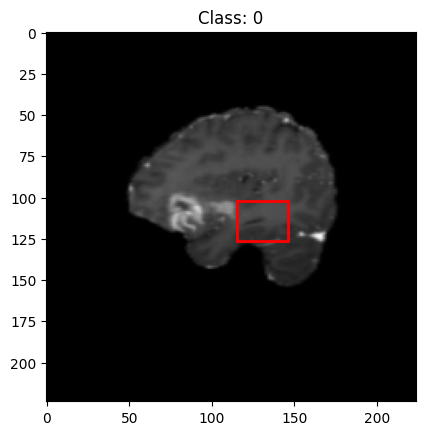

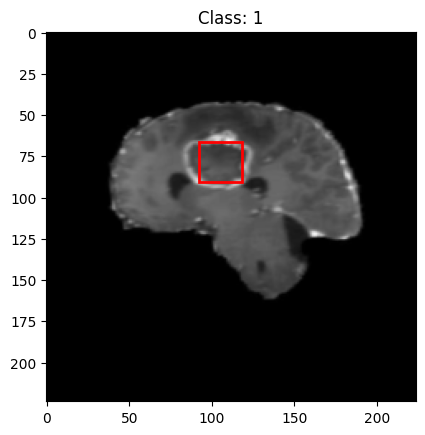

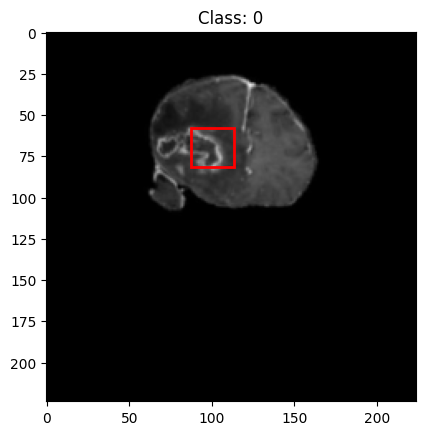

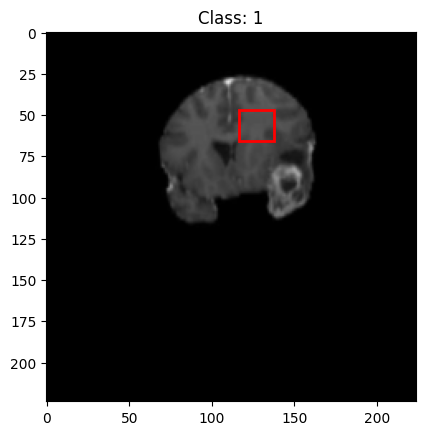

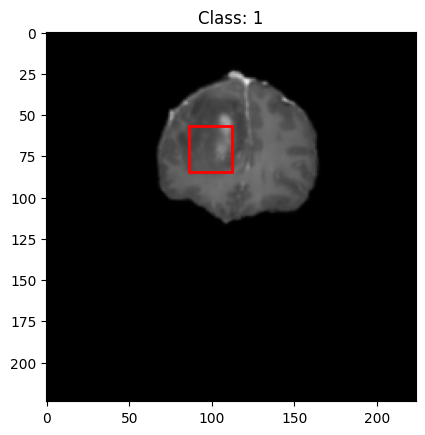

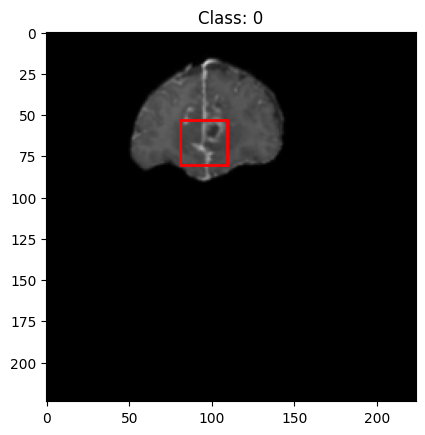

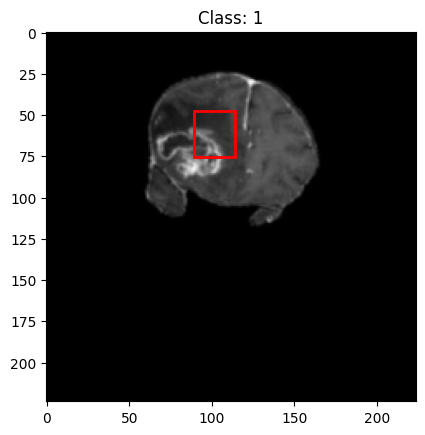

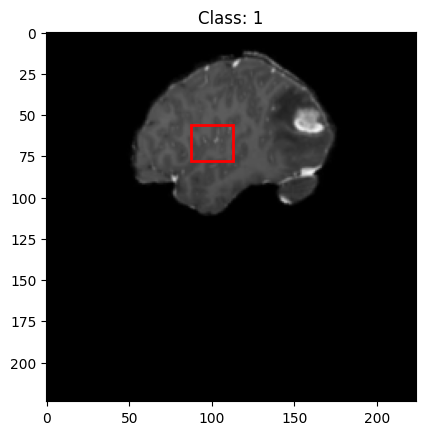

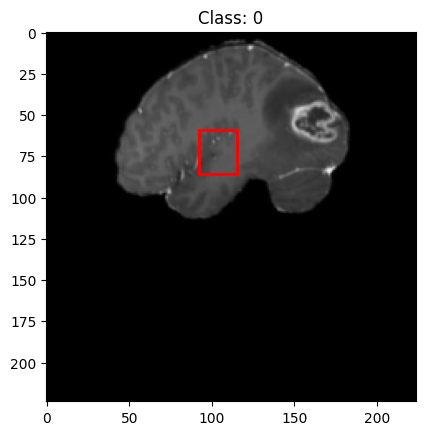

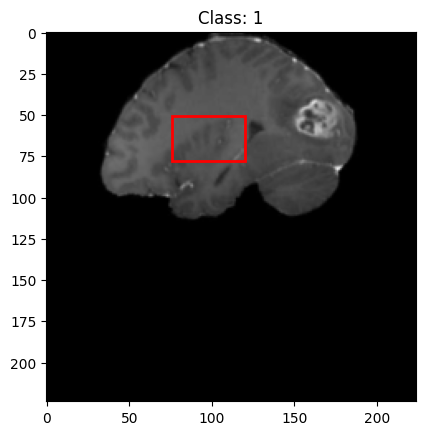

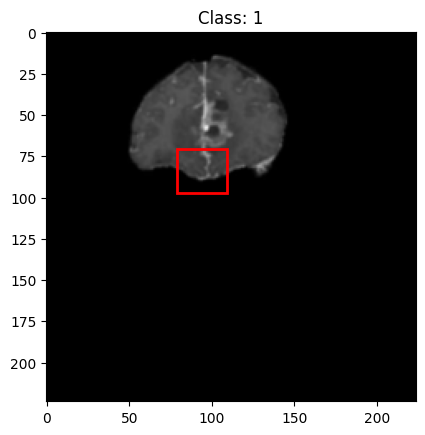

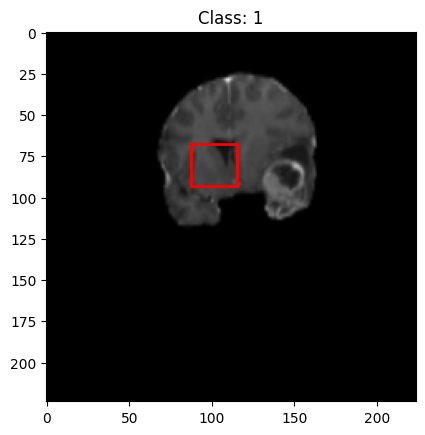

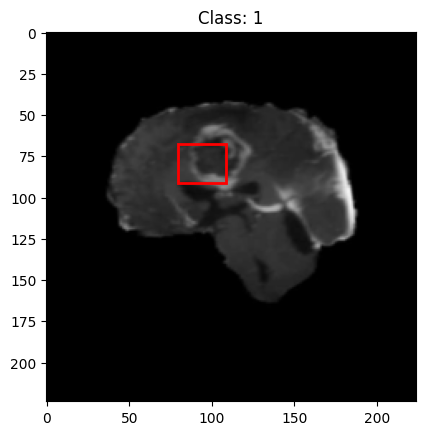

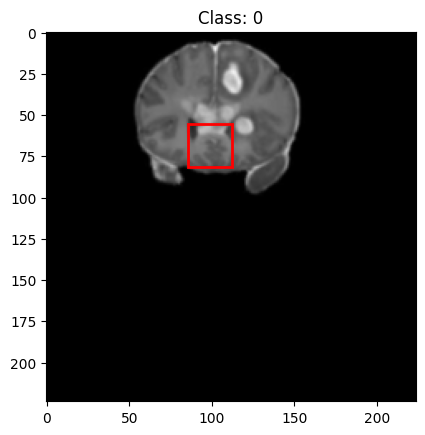

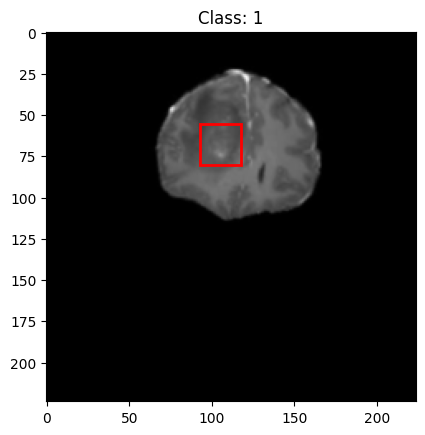

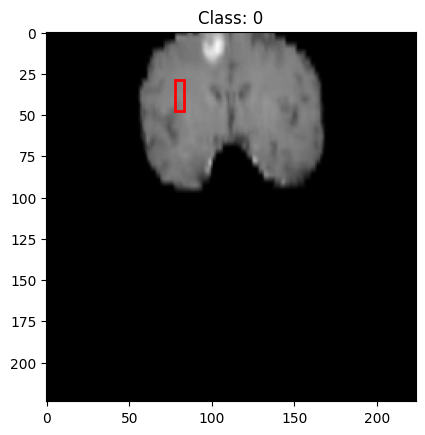

In [10]:
model.eval()
with torch.no_grad():
    for batch in val_loader:
        images, targets = zip(*batch)   
        images = torch.stack(images).to(device)
        preds = model(images)
        
        for j in range(images.size(0)):
            pred_bbox = preds[j,:,0,0][:4]
            pred_cls = torch.argmax(preds[j,:,0,0][5:])
            plot_prediction(images[j], pred_bbox, pred_cls)
        break 

## Вывод

Реализована YOLO-подобная модель для детекции опухолей мозга на датасете Ultralytics/Brain-tumor с предобученным ResNet50 в качестве backbone. Использована комбинированная функция потерь, проведено обучение, предсказания обработаны NMS и визуализированы. Результаты показывают адекватное выявление областей опухоли на изображениях.

Работа выполнена Гареевой Д.Р (507540), j4150